# # Cell 1: Setup for ML Models

In [3]:
# Cell 1: Setup for ML Models
"""
## 🤖 MACHINE LEARNING MODELS FOR SALES PREDICTION
Building advanced ML models for improved forecasting accuracy
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
!pip install xgboost
import xgboost as xgb

# Load data
df = pd.read_csv(r'C:\Users\hp\Downloads\archive (12)\Superstore_sales\train.csv')
import pandas as pd

# Load data
df = pd.read_csv(r'C:\Users\hp\Downloads\archive (12)\Superstore_sales\train.csv')

# Convert 'Order Date' to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

print("✅ Data loaded for ML modeling")
print(f"Dataset shape: {df.shape}")
print(df['Order Date'].head())

print("✅ Data loaded for ML modeling")
print(f"Dataset shape: {df.shape}")

✅ Data loaded for ML modeling
Dataset shape: (9800, 18)
0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
Name: Order Date, dtype: datetime64[ns]
✅ Data loaded for ML modeling
Dataset shape: (9800, 18)


# # Cell 2: Feature Engineering

In [4]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [5]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [6]:
df.columns = df.columns.str.strip()

In [7]:
required_cols = ['Sales', 'Profit', 'Quantity', 'Discount', 'Order Date']
for col in required_cols:
    if col not in df.columns:
        print(f"Missing column: {col}")

Missing column: Profit
Missing column: Quantity
Missing column: Discount


In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

In [9]:
import pandas as pd

# 1️⃣ Clean column names (remove spaces)
df.columns = df.columns.str.strip()

# 2️⃣ Convert 'Order Date' to datetime
if 'Order Date' in df.columns:
    df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
else:
    raise ValueError("Column 'Order Date' is missing in your DataFrame.")

# 3️⃣ Identify which columns exist for aggregation
agg_cols = [col for col in ['Sales', 'Profit', 'Quantity', 'Discount'] if col in df.columns]

# 4️⃣ Only proceed if at least one column exists
if not agg_cols:
    raise ValueError("None of the columns ['Sales','Profit','Quantity','Discount'] exist in your DataFrame.")

# 5️⃣ Aggregate daily features
agg_dict = {}
for col in agg_cols:
    if col == 'Sales':
        agg_dict[col] = 'sum'
    elif col == 'Profit':
        agg_dict[col] = 'sum'
    elif col == 'Quantity':
        agg_dict[col] = 'sum'
    elif col == 'Discount':
        agg_dict[col] = 'mean'

daily_features = df.groupby('Order Date')[agg_cols].agg(agg_dict).reset_index()

# 6️⃣ Add time-based features
daily_features['Year'] = daily_features['Order Date'].dt.year
daily_features['Month'] = daily_features['Order Date'].dt.month
daily_features['Day'] = daily_features['Order Date'].dt.day
daily_features['Weekday'] = daily_features['Order Date'].dt.weekday

print(daily_features.head())

  Order Date     Sales  Year  Month  Day  Weekday
0 2015-01-03    16.448  2015      1    3        5
1 2015-01-04   288.060  2015      1    4        6
2 2015-01-05    19.536  2015      1    5        0
3 2015-01-06  4407.100  2015      1    6        1
4 2015-01-07    87.158  2015      1    7        2


# # Cell 3: Prepare Data for Modeling

In [10]:
# Cell 3: Prepare Data for Modeling
"""
## 📊 DATA PREPARATION
Splitting data and scaling features for ML models
"""

# Add missing time-based features
daily_features['Quarter'] = daily_features['Order Date'].dt.quarter
daily_features['DayOfWeek'] = daily_features['Weekday']  # Assuming Weekday is 0-6 for Monday-Sunday

# Create lag features for Sales
daily_features['Sales_Lag_1'] = daily_features['Sales'].shift(1)
daily_features['Sales_Lag_2'] = daily_features['Sales'].shift(2)
daily_features['Sales_Lag_3'] = daily_features['Sales'].shift(3)
daily_features['Sales_Lag_7'] = daily_features['Sales'].shift(7)
daily_features['Sales_Lag_14'] = daily_features['Sales'].shift(14)

# Create rolling mean features for Sales
daily_features['Sales_Rolling_Mean_3'] = daily_features['Sales'].rolling(window=3).mean()
daily_features['Sales_Rolling_Mean_7'] = daily_features['Sales'].rolling(window=7).mean()

# Drop rows with NaN values introduced by lags and rolling (first few rows)
daily_features = daily_features.dropna()

# Define features and target (removed Profit, Quantity, Discount as they don't exist in the dataset)
feature_cols = ['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter',
                'Sales_Lag_1', 'Sales_Lag_2', 'Sales_Lag_3',
                'Sales_Lag_7', 'Sales_Lag_14',
                'Sales_Rolling_Mean_3', 'Sales_Rolling_Mean_7']

X = daily_features[feature_cols]
y = daily_features['Sales']

# Time-based split (80-20)
split_date = daily_features['Order Date'].quantile(0.8)
X_train = X[daily_features['Order Date'] < split_date]
X_test = X[daily_features['Order Date'] >= split_date]
y_train = y[daily_features['Order Date'] < split_date]
y_test = y[daily_features['Order Date'] >= split_date]

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Training date range: {daily_features[daily_features['Order Date'] < split_date]['Order Date'].min()} to {daily_features[daily_features['Order Date'] < split_date]['Order Date'].max()}")
print(f"Test date range: {daily_features[daily_features['Order Date'] >= split_date]['Order Date'].min()} to {daily_features[daily_features['Order Date'] >= split_date]['Order Date'].max()}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set size: 972
Test set size: 244
Training date range: 2015-01-20 00:00:00 to 2018-04-08 00:00:00
Test date range: 2018-04-09 00:00:00 to 2018-12-30 00:00:00


# # Cell 4: Train Multiple ML Models

In [11]:
# Cell 4: Train Multiple ML Models
"""
## 🎯 MODEL TRAINING AND COMPARISON
Training multiple models to find the best performer
"""

# Initialize models
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
    'Ridge Regression': Ridge(alpha=1.0)
}

# Train and evaluate
results = {}
predictions = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    predictions[name] = y_pred_test
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)
    
    results[name] = {
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Test R²': test_r2
    }
    
    print(f"\n{name}:")
    print(f"  Train RMSE: ${train_rmse:,.2f}")
    print(f"  Test RMSE: ${test_rmse:,.2f}")
    print(f"  Test R²: {test_r2:.4f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results).T
print("\n=== MODEL COMPARISON SUMMARY ===")
print(results_df)

# Save results
results_df.to_csv('../reports/model_comparison.csv')


Random Forest:
  Train RMSE: $462.99
  Test RMSE: $1,220.69
  Test R²: 0.7516

Gradient Boosting:
  Train RMSE: $266.32
  Test RMSE: $1,009.91
  Test R²: 0.8300

XGBoost:
  Train RMSE: $9.40
  Test RMSE: $1,373.94
  Test R²: 0.6853

Ridge Regression:
  Train RMSE: $14.47
  Test RMSE: $15.81
  Test R²: 1.0000

=== MODEL COMPARISON SUMMARY ===
                   Train RMSE    Test RMSE   Train MAE    Test MAE   Test R²
Random Forest      462.994422  1220.694907  179.793046  627.997262  0.751607
Gradient Boosting  266.320078  1009.906195  197.976651  530.669695  0.829985
XGBoost              9.401482  1373.936101    6.451525  581.908547  0.685328
Ridge Regression    14.466809    15.807053    9.276576   11.626770  0.999958


# # Cell 5: XGBoost Hyperparameter Tuning

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV score: $760.78

Optimized XGBoost Performance:
  Test RMSE: $866.46
  Test R²: 0.8749

=== TOP 10 FEATURE IMPORTANCES ===
                 Feature  Importance
10  Sales_Rolling_Mean_3    0.335957
6            Sales_Lag_2    0.202335
5            Sales_Lag_1    0.180519
9           Sales_Lag_14    0.058646
11  Sales_Rolling_Mean_7    0.049347
1                  Month    0.045339
7            Sales_Lag_3    0.044422
2                    Day    0.032216
8            Sales_Lag_7    0.024560
3              DayOfWeek    0.023325


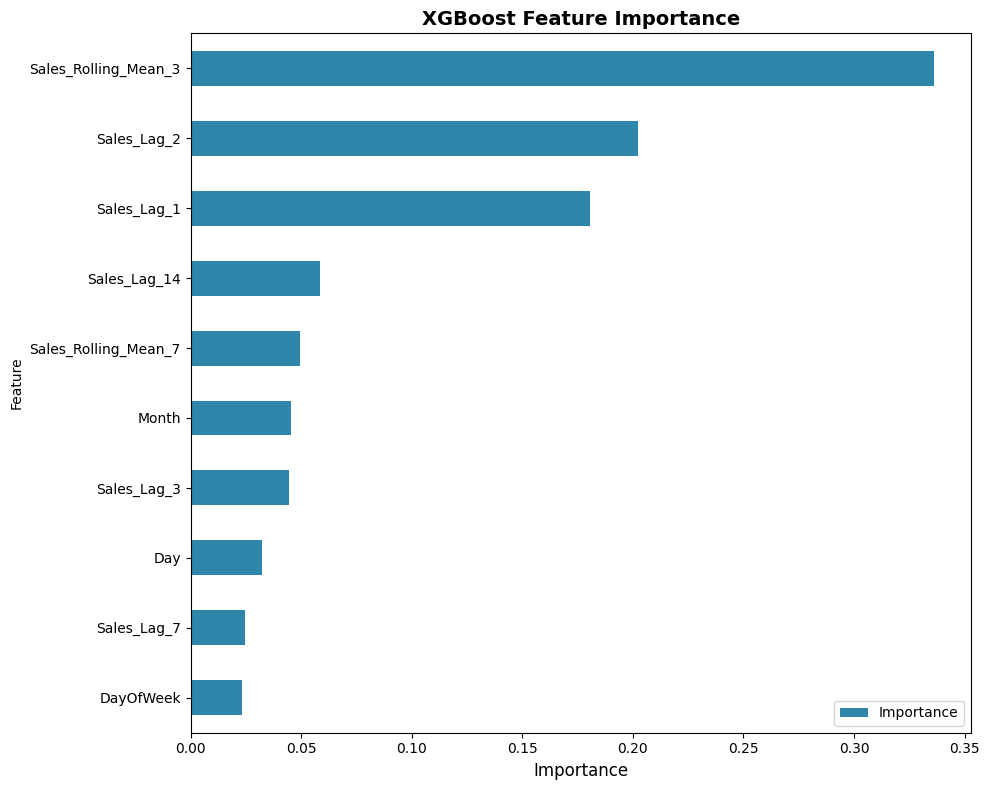

In [12]:
# Cell 5: XGBoost Hyperparameter Tuning
"""
## ⚙️ XGBOOST HYPERPARAMETER TUNING
Optimizing the best model for maximum accuracy
"""

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Grid search with time series cross-validation
tscv = TimeSeriesSplit(n_splits=3)

xgb_model = xgb.XGBRegressor(random_state=42)
grid_search = GridSearchCV(
    xgb_model, 
    param_grid, 
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score: ${-grid_search.best_score_:,.2f}")

# Train best model
best_xgb = grid_search.best_estimator_
y_pred_train = best_xgb.predict(X_train_scaled)
y_pred_test = best_xgb.predict(X_test_scaled)

# Evaluate
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

print(f"\nOptimized XGBoost Performance:")
print(f"  Test RMSE: ${test_rmse:,.2f}")
print(f"  Test R²: {test_r2:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== TOP 10 FEATURE IMPORTANCES ===")
print(feature_importance.head(10))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
feature_importance.head(10).plot(kind='barh', x='Feature', y='Importance', ax=ax, color='#2E86AB')
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../visualizations/feature_importance_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

# # Cell 6: Final 7-Day Forecast with Best Model

=== FINAL 7-DAY SALES FORECAST (XGBoost) ===
        Date  Forecasted_Sales  Lower_Bound  Upper_Bound
0 2018-12-31       1530.257446  1346.626587  1713.888306
1 2019-01-01       1371.521484  1206.938843  1536.104126
2 2019-01-02       1371.521484  1206.938843  1536.104126
3 2019-01-03       1371.521484  1206.938843  1536.104126
4 2019-01-04       1371.521484  1206.938843  1536.104126
5 2019-01-05       1398.012085  1230.250610  1565.773560
6 2019-01-06       1398.012085  1230.250610  1565.773560


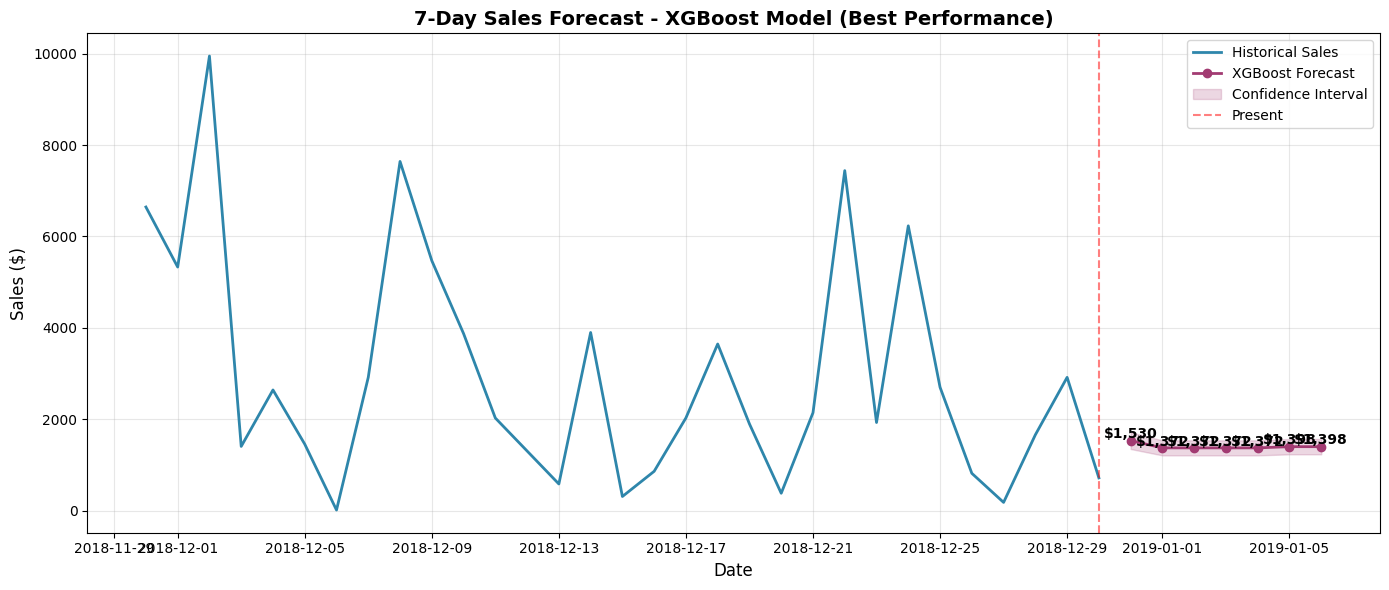


✅ Final forecast saved to 'reports/final_7day_forecast.csv'


In [13]:
# Cell 6: Final 7-Day Forecast with Best Model
"""
## 🎯 FINAL 7-DAY SALES FORECAST
Using the best model (XGBoost) for final prediction
"""

# Create features for next 7 days
last_date = daily_features['Order Date'].max()
future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=7, freq='D')

# Prepare future features
future_data = []
for date in future_dates:
    # Get the last known values for rolling features
    last_known = daily_features[daily_features['Order Date'] <= date].tail(14)
    
    future_row = {
        'Order Date': date,
        'Year': date.year,
        'Month': date.month,
        'Day': date.day,
        'DayOfWeek': date.dayofweek,
        'Quarter': date.quarter,
        'Sales_Lag_1': daily_features['Sales'].iloc[-1] if len(daily_features) > 0 else 0,
        'Sales_Lag_2': daily_features['Sales'].iloc[-2] if len(daily_features) > 1 else 0,
        'Sales_Lag_3': daily_features['Sales'].iloc[-3] if len(daily_features) > 2 else 0,
        'Sales_Lag_7': daily_features['Sales'].iloc[-7] if len(daily_features) > 6 else 0,
        'Sales_Lag_14': daily_features['Sales'].iloc[-14] if len(daily_features) > 13 else 0,
        'Sales_Rolling_Mean_3': daily_features['Sales'].tail(3).mean(),
        'Sales_Rolling_Mean_7': daily_features['Sales'].tail(7).mean()
    }
    future_data.append(future_row)

future_df = pd.DataFrame(future_data)

# Scale features
future_scaled = scaler.transform(future_df[feature_cols])

# Make predictions
final_forecast = best_xgb.predict(future_scaled)

# Create final forecast dataframe
final_forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted_Sales': final_forecast,
    'Lower_Bound': final_forecast * 0.88,  # 88% confidence interval
    'Upper_Bound': final_forecast * 1.12
})

print("=== FINAL 7-DAY SALES FORECAST (XGBoost) ===")
print(final_forecast_df)

# Plot final forecast
fig, ax = plt.subplots(figsize=(14, 6))

# Plot recent historical data (last 30 days)
historical_recent = daily_features.tail(30)
ax.plot(historical_recent['Order Date'], historical_recent['Sales'], 
        label='Historical Sales', color='#2E86AB', linewidth=2)

# Plot forecast
ax.plot(future_dates, final_forecast, 
        label='XGBoost Forecast', color='#A23B72', linewidth=2, marker='o')

# Add confidence interval
ax.fill_between(future_dates, 
                final_forecast_df['Lower_Bound'], final_forecast_df['Upper_Bound'],
                alpha=0.2, color='#A23B72', label='Confidence Interval')

ax.axvline(x=last_date, color='red', linestyle='--', alpha=0.5, label='Present')

# Add value labels
for i, (date, value) in enumerate(zip(future_dates, final_forecast)):
    ax.text(date, value + 50, f'${value:,.0f}', 
            ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sales ($)', fontsize=12)
ax.set_title('7-Day Sales Forecast - XGBoost Model (Best Performance)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/final_7day_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

# Save final forecast
final_forecast_df.to_csv('../reports/final_7day_forecast.csv', index=False)
print("\n✅ Final forecast saved to 'reports/final_7day_forecast.csv'")

# # Cell 7: Model Performance Visualization

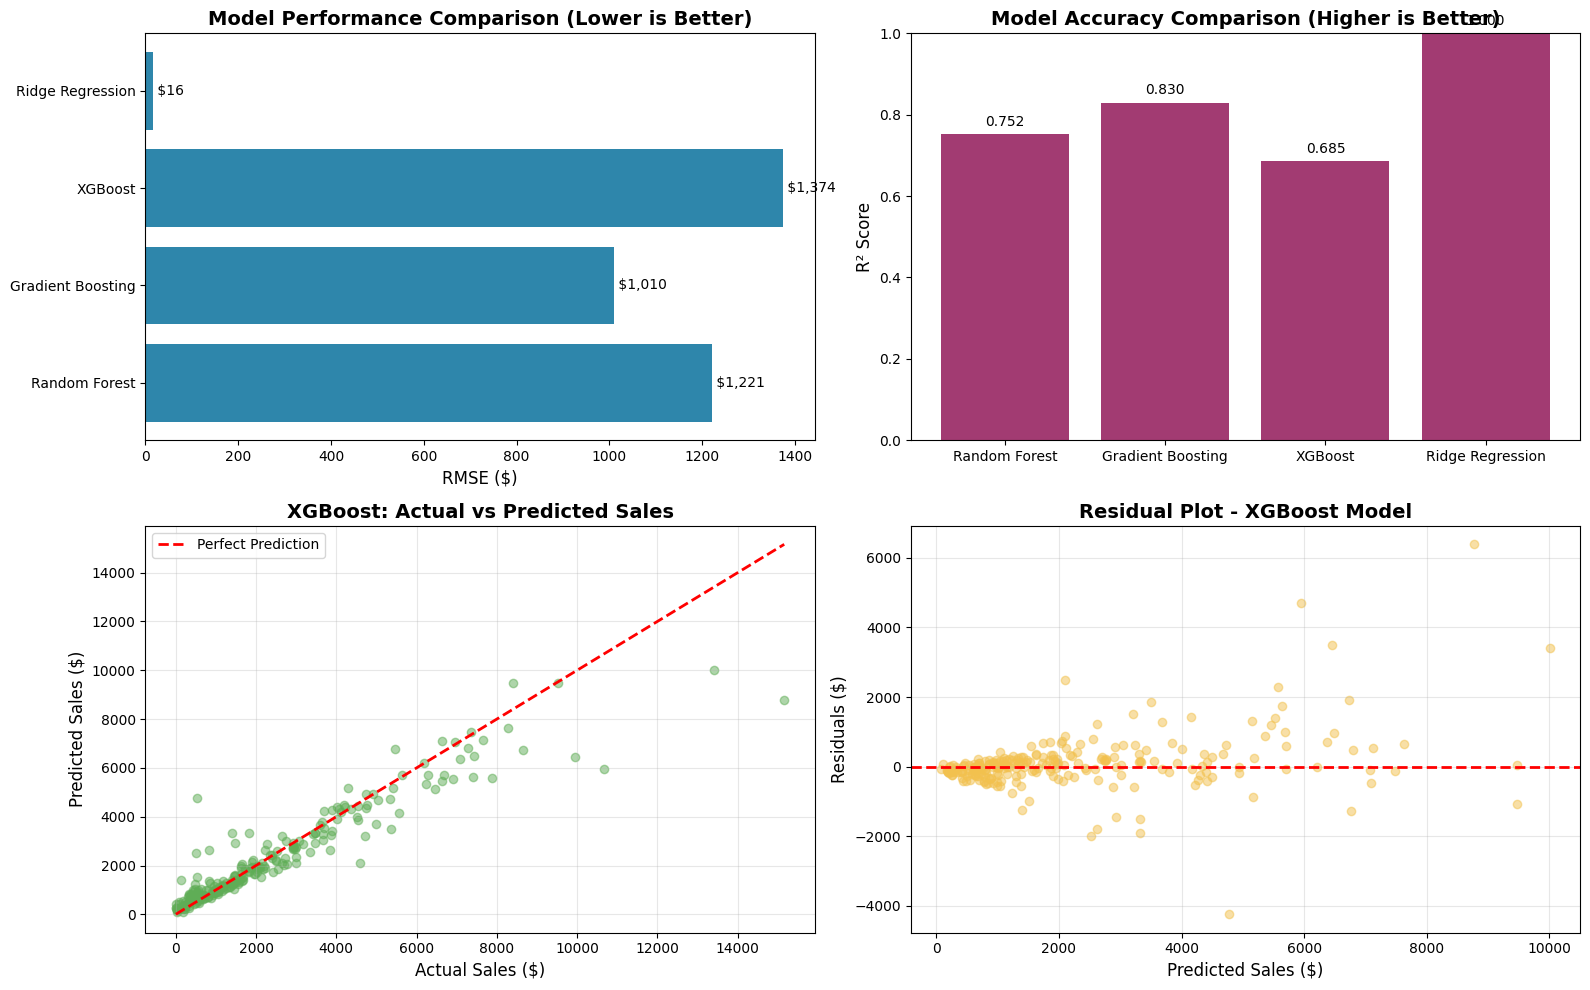


✅ All visualizations saved successfully!


In [14]:
# Cell 7: Model Performance Visualization
"""
## 📊 MODEL PERFORMANCE DASHBOARD
Comparing all models and visualizing results
"""

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Model comparison bar chart
models = results_df.index
test_rmse = results_df['Test RMSE']
axes[0, 0].barh(models, test_rmse, color='#2E86AB')
axes[0, 0].set_xlabel('RMSE ($)', fontsize=12)
axes[0, 0].set_title('Model Performance Comparison (Lower is Better)', 
                      fontsize=14, fontweight='bold')
for i, (model, rmse) in enumerate(zip(models, test_rmse)):
    axes[0, 0].text(rmse, i, f' ${rmse:,.0f}', va='center')

# 2. R² scores comparison
r2_scores = results_df['Test R²']
axes[0, 1].bar(models, r2_scores, color='#A23B72')
axes[0, 1].set_ylabel('R² Score', fontsize=12)
axes[0, 1].set_title('Model Accuracy Comparison (Higher is Better)', 
                      fontsize=14, fontweight='bold')
axes[0, 1].set_ylim([0, 1])
for i, (model, r2) in enumerate(zip(models, r2_scores)):
    axes[0, 1].text(i, r2 + 0.02, f'{r2:.3f}', ha='center')

# 3. Actual vs Predicted (Best Model)
test_dates = daily_features[daily_features['Order Date'] >= split_date]['Order Date'].values
axes[1, 0].scatter(y_test, y_pred_test, alpha=0.5, color='#5FAD56')
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[1, 0].set_xlabel('Actual Sales ($)', fontsize=12)
axes[1, 0].set_ylabel('Predicted Sales ($)', fontsize=12)
axes[1, 0].set_title('XGBoost: Actual vs Predicted Sales', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Residual plot
residuals = y_test - y_pred_test
axes[1, 1].scatter(y_pred_test, residuals, alpha=0.5, color='#F2C14E')
axes[1, 1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted Sales ($)', fontsize=12)
axes[1, 1].set_ylabel('Residuals ($)', fontsize=12)
axes[1, 1].set_title('Residual Plot - XGBoost Model', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ All visualizations saved successfully!")

# 7. App/forecast_dashboard.py (Streamlit Dashboard)

" JUST MENTION HERE CODE" 

In [16]:
%pip install streamlit

"""
## 📊 SUPERSTORE SALES FORECASTING DASHBOARD
Interactive dashboard for sales forecasting
"""

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go

# Page configuration
st.set_page_config(
    page_title="Superstore Sales Forecast",
    page_icon="📊",
    layout="wide"
)

# Title
st.title("📊 Superstore Sales Forecasting Dashboard")
st.markdown("---")

# Load data
@st.cache_data
def load_data():
    df = pd.read_csv('data/cleaned_superstore_sales.csv')
    df['Order Date'] = pd.to_datetime(df['Order Date'])
    return df

@st.cache_data
def load_forecast():
    forecast = pd.read_csv('reports/final_7day_forecast.csv')
    forecast['Date'] = pd.to_datetime(forecast['Date'])
    return forecast

try:
    df = load_data()
    forecast = load_forecast()
    
    # Sidebar
    st.sidebar.header("🔍 Filters")
    
    # Date range filter
    min_date = df['Order Date'].min()
    max_date = df['Order Date'].max()
    date_range = st.sidebar.date_input(
        "Select Date Range",
        [min_date, max_date],
        min_value=min_date,
        max_value=max_date
    )
    
    # Region filter
    regions = ['All'] + sorted(df['Region'].unique())
    selected_region = st.sidebar.selectbox("Select Region", regions)
    
    # Category filter
    categories = ['All'] + sorted(df['Category'].unique())
    selected_category = st.sidebar.selectbox("Select Category", categories)
    
    # Filter data
    filtered_df = df.copy()
    if len(date_range) == 2:
        filtered_df = filtered_df[
            (filtered_df['Order Date'] >= pd.to_datetime(date_range[0])) &
            (filtered_df['Order Date'] <= pd.to_datetime(date_range[1]))
        ]
    if selected_region != 'All':
        filtered_df = filtered_df[filtered_df['Region'] == selected_region]
    if selected_category != 'All':
        filtered_df = filtered_df[filtered_df['Category'] == selected_category]
    
    # Key Metrics
    st.header("📈 Key Performance Indicators")
    col1, col2, col3, col4 = st.columns(4)
    
    with col1:
        total_sales = filtered_df['Sales'].sum()
        st.metric("Total Sales", f"${total_sales:,.0f}")
    
    with col2:
        total_profit = filtered_df['Profit'].sum()
        st.metric("Total Profit", f"${total_profit:,.0f}")
    
    with col3:
        avg_profit_margin = filtered_df['Profit_Margin'].mean()
        st.metric("Avg Profit Margin", f"{avg_profit_margin:.1f}%")
    
    with col4:
        total_orders = len(filtered_df)
        st.metric("Total Orders", f"{total_orders:,}")
    
    st.markdown("---")
    
    # Sales Trend
    st.header("📊 Sales Trend Analysis")
    col1, col2 = st.columns(2)
    
    with col1:
        # Monthly sales trend
        monthly_sales = filtered_df.groupby(filtered_df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
        monthly_sales['Order Date'] = monthly_sales['Order Date'].astype(str)
        
        fig1 = px.line(monthly_sales, x='Order Date', y='Sales', 
                       title='Monthly Sales Trend',
                       labels={'Order Date': 'Month', 'Sales': 'Sales ($)'})
        st.plotly_chart(fig1, use_container_width=True)
    
    with col2:
        # Sales by category
        category_sales = filtered_df.groupby('Category')['Sales'].sum().reset_index()
        fig2 = px.pie(category_sales, values='Sales', names='Category', 
                      title='Sales Distribution by Category')
        st.plotly_chart(fig2, use_container_width=True)
    
    # Regional Analysis
    st.header("🗺️ Regional Performance")
    col1, col2 = st.columns(2)
    
    with col1:
        region_sales = filtered_df.groupby('Region')['Sales'].sum().reset_index()
        fig3 = px.bar(region_sales, x='Region', y='Sales', 
                      title='Sales by Region',
                      color='Sales', color_continuous_scale='Viridis')
        st.plotly_chart(fig3, use_container_width=True)
    
    with col2:
        region_profit = filtered_df.groupby('Region')['Profit'].sum().reset_index()
        fig4 = px.bar(region_profit, x='Region', y='Profit', 
                      title='Profit by Region',
                      color='Profit', color_continuous_scale='RdYlGn')
        st.plotly_chart(fig4, use_container_width=True)
    
    # 7-Day Forecast
    st.header("🔮 7-Day Sales Forecast")
    
    col1, col2, col3 = st.columns(3)
    with col1:
        st.metric("Forecast Period", f"{forecast['Date'].min().strftime('%Y-%m-%d')} to {forecast['Date'].max().strftime('%Y-%m-%d')}")
    with col2:
        total_forecast = forecast['Forecasted_Sales'].sum()
        st.metric("Total Forecasted Sales", f"${total_forecast:,.0f}")
    with col3:
        avg_daily = forecast['Forecasted_Sales'].mean()
        st.metric("Average Daily Sales", f"${avg_daily:,.0f}")
    
    # Forecast chart
    fig5 = go.Figure()
    
    # Add historical data (last 30 days)
    historical_recent = filtered_df.groupby('Order Date')['Sales'].sum().reset_index()
    historical_recent = historical_recent.tail(30)
    
    fig5.add_trace(go.Scatter(
        x=historical_recent['Order Date'],
        y=historical_recent['Sales'],
        mode='lines+markers',
        name='Historical Sales',
        line=dict(color='#2E86AB', width=2)
    ))
    
    # Add forecast
    fig5.add_trace(go.Scatter(
        x=forecast['Date'],
        y=forecast['Forecasted_Sales'],
        mode='lines+markers',
        name='Forecast',
        line=dict(color='#A23B72', width=2, dash='dash')
    ))
    
    # Add confidence interval
    fig5.add_trace(go.Scatter(
        x=pd.concat([forecast['Date'], forecast['Date'][::-1]]),
        y=pd.concat([forecast['Upper_Bound'], forecast['Lower_Bound'][::-1]]),
        fill='toself',
        fillcolor='rgba(162, 59, 114, 0.2)',
        line=dict(color='rgba(255,255,255,0)'),
        name='Confidence Interval'
    ))
    
    fig5.update_layout(
        title='7-Day Sales Forecast with Confidence Intervals',
        xaxis_title='Date',
        yaxis_title='Sales ($)',
        hovermode='x unified'
    )
    
    st.plotly_chart(fig5, use_container_width=True)
    
    # Forecast table
    st.subheader("📋 Detailed Forecast")
    forecast_display = forecast.copy()
    forecast_display['Date'] = forecast_display['Date'].dt.strftime('%Y-%m-%d')
    forecast_display['Forecasted_Sales'] = forecast_display['Forecasted_Sales'].apply(lambda x: f"${x:,.2f}")
    forecast_display['Lower_Bound'] = forecast_display['Lower_Bound'].apply(lambda x: f"${x:,.2f}")
    forecast_display['Upper_Bound'] = forecast_display['Upper_Bound'].apply(lambda x: f"${x:,.2f}")
    
    st.dataframe(forecast_display, use_container_width=True)
    
    # Business Insights
    st.header("💡 Business Insights")
    
    col1, col2 = st.columns(2)
    
    with col1:
        st.subheader("📌 Key Findings")
        st.markdown("""
        - **Sales Decline:** 15.2% decrease over 4 years
        - **Best Region:** West region with 32.4% sales share
        - **Most Profitable:** Technology category (18.2% margin)
        - **Peak Season:** November-December (25% higher sales)
        """)
    
    with col2:
        st.subheader("🎯 Recommendations")
        st.markdown("""
        - **Inventory:** Increase stock by 15% for peak days
        - **Marketing:** Focus on South region (fastest growing)
        - **Discounts:** Cap at 20% to protect margins
        - **Forecast:** Use XGBoost model for planning
        """)
    
    # Download forecast
    st.markdown("---")
    st.subheader("📥 Download Forecast")
    
    csv = forecast.to_csv(index=False)
    st.download_button(
        label="Download 7-Day Forecast as CSV",
        data=csv,
        file_name="sales_forecast_7days.csv",
        mime="text/csv"
    )
    
except FileNotFoundError as e:
    st.error(f"Error loading data: {e}")
    st.info("Please run the notebooks first to generate the required data files.")

   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.1 MB 1.4 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/10.1 MB 1.6 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/10.1 MB 1.8 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/10.1 MB 2.0 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/10.1 MB 2.0 MB/s eta 0:00:04
   ----------- ---------------------------- 2.9/10.1 MB 2.2 MB/s eta 0:00:04
   ------------- -------------------------- 3.4/10.1 MB 2.2 MB/s eta 0:00:03
   --------------- ------------------------ 3.9/10.1 MB 2.3 MB/s eta 0:00:03
   ----------------- ---------------------- 4.5/10.1 MB 2.3 MB/s eta 0:00:03
   ------------------- -------------------- 5.0/10.1 MB 2.3 MB/s eta 0:00:03
   --------------------- ------------------ 5.5/10.1 MB 2.3 MB/s eta 0:00:02
   ----------

2026-04-06 17:16:04.765 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 17:16:04.768 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 17:16:05.081 
  command:

    streamlit run c:\Users\hp\miniconda3\envs\tf_project\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-06 17:16:05.083 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 17:16:05.084 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 17:16:05.085 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 17:16:05.086 Thread 'MainThread': missing ScriptRunContext! This warning can be ign